# Обучение модели

CatBoost на очищенном датасете из `01_preprocessing.ipynb`. Классы сильно несбалансированы (целевых действий около 6.5%), поэтому веса классов выравниваются через `auto_class_weights`

In [1]:
import pickle

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split

In [2]:
data_df = pd.read_csv("../data/data.csv", low_memory=False)
print(data_df.shape)
data_df["event_action"].value_counts(normalize=True)

(326341, 11)


event_action
0    0.935068
1    0.064932
Name: proportion, dtype: float64

In [3]:
X = data_df.drop("event_action", axis=1)
y = data_df["event_action"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

In [4]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    l2_leaf_reg=0.2,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=200,
)
model.fit(X_train, y_train)

0:	learn: 0.6847125	total: 88.5ms	remaining: 1m 28s


200:	learn: 0.5777487	total: 6.44s	remaining: 25.6s


400:	learn: 0.5496376	total: 12.9s	remaining: 19.2s


600:	learn: 0.5280642	total: 19.1s	remaining: 12.7s


800:	learn: 0.5104147	total: 25.3s	remaining: 6.29s


999:	learn: 0.4954315	total: 31.5s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', iterations=1000, l2_leaf_reg=0.2, learning_rate=0.1, random_seed=42, verbose=200)

In [5]:
auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC train: {auc_train:.3f}")
print(f"ROC-AUC test:  {auc_test:.3f}")

ROC-AUC train: 0.844
ROC-AUC test:  0.765


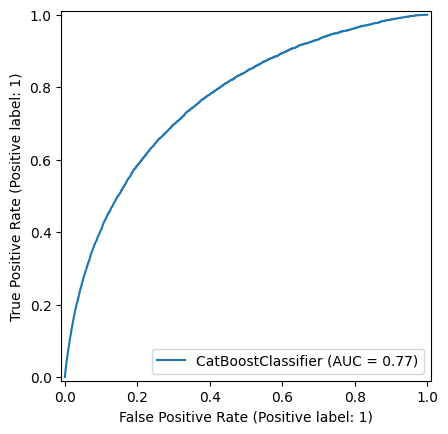

In [6]:
RocCurveDisplay.from_estimator(model, X_test, y_test);

In [7]:
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

geo_city                    20.446287
device_screen_resolution    16.784725
utm_campaign                13.336867
utm_source                  11.413134
utm_adcontent                9.073254
device_brand                 8.854085
device_browser               6.548417
geo_country                  6.276707
utm_medium                   5.895013
device_category              1.371510
dtype: float64

In [8]:
# Проверка на одной строке: подаём только признаки, без целевой колонки
sample = X.iloc[[59]]
print("Прогноз:", model.predict(sample)[0], "| факт:", y.iloc[59])

Прогноз: 1 | факт: 1


In [9]:
with open("../model/model.pickle", "wb") as f:
    pickle.dump(model, f)